# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print("So dong:", df.shape[0], "So cot:", df.shape[1])
df.info()

So dong: 891 So cot: 15
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [3]:
print(df.isnull().sum())
print("So dong bi trung:", df.duplicated().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
So dong bi trung: 107


## A.3. Invalid values

In [4]:
print("age <= 0:", (df['age']<=0).sum())
print("fare < 0:", (df['fare']<0).sum())
print("sibsp < 0:", (df['sibsp']<0).sum())
print("parch < 0:", (df['parch']<0).sum())

age <= 0: 0
fare < 0: 0
sibsp < 0: 0
parch < 0: 0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [5]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df[['sibsp','parch','family_size']].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
for col in ['age','fare','family_size']:
    print(col, "- mean:", df[col].mean(), "median:", df[col].median(), "mode:", df[col].mode()[0])

age - mean: 29.69911764705882 median: 28.0 mode: 24.0
fare - mean: 32.204207968574636 median: 14.4542 mode: 8.05
family_size - mean: 1.904601571268238 median: 1.0 mode: 1


## Group 2 — Dispersion

In [7]:
for col in ['age','fare','family_size']:
    s = df[col].dropna()
    print(col)
    print("Range:", s.max()-s.min())
    print("Std:", s.std())
    print("IQR:", s.quantile(0.75)-s.quantile(0.25))
    print("CV:", s.std()/s.mean())

age
Range: 79.58
Std: 14.526497332334042
IQR: 17.875
CV: 0.4891221855465675
fare
Range: 512.3292
Std: 49.6934285971809
IQR: 23.0896
CV: 1.5430725278408497
family_size
Range: 10
Std: 1.6134585413550873
IQR: 1.0
CV: 0.8471370420432426


## Group 3 — Location and Shape

age - skew: 0.38828985146986567 kurtosis: 0.16863657224286044
fare - skew: 4.7792532923723545 kurtosis: 33.20428925264474


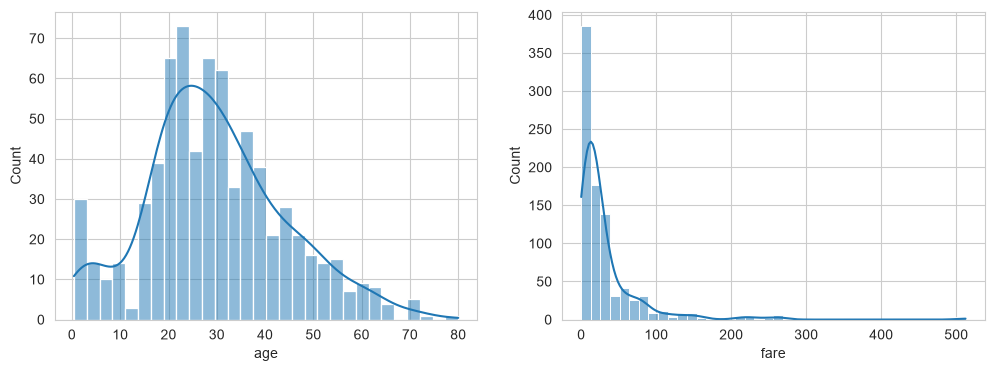

In [8]:
for col in ['age','fare']:
    s = df[col].dropna()
    print(col, "- skew:", stats.skew(s), "kurtosis:", stats.kurtosis(s))

fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=axes[0])
sns.histplot(df['fare'], bins=40, kde=True, ax=axes[1])
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [9]:
survival_by_class = df.groupby('pclass')['survived'].mean() * 100
print(survival_by_class)

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [10]:
print(df.groupby('sex')['survived'].mean()*100)
print(df.groupby('pclass')['survived'].mean()*100)

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [11]:
print("Tuong quan fare-survived:", df['fare'].corr(df['survived']))

df['fare_bin'] = pd.qcut(df['fare'], 4)
print(df.groupby('fare_bin', observed=True)['survived'].mean()*100)

Tuong quan fare-survived: 0.2573065223849622
fare_bin
(-0.001, 7.91]     19.730942
(7.91, 14.454]     30.357143
(14.454, 31.0]     45.495495
(31.0, 512.329]    58.108108
Name: survived, dtype: float64


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [12]:
print(df.groupby('family_size')['survived'].mean()*100)

family_size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: survived, dtype: float64


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [13]:
print(df.groupby('embark_town')['survived'].mean().sort_values(ascending=False)*100)

embark_town
Cherbourg      55.357143
Queenstown     38.961039
Southampton    33.695652
Name: survived, dtype: float64


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

*Insight:*

Dữ liệu 891 dòng, thiếu khá nhiều ở cột age, deck và vài dòng ở embarked/embark_town. Nữ sống sót nhiều hơn nam rất nhiều (khoảng 74% so với 19%), và hạng vé 1 sống sót cao hơn hẳn hạng 3 (63% so với 24%) — vé càng đắt thì tỷ lệ sống sót cũng càng cao. Gia đình vừa (2-4 người) sống sót cao hơn người đi 1 mình hoặc gia đình quá đông. Cảng Cherbourg có tỷ lệ sống sót cao nhất trong 3 cảng. Nhìn chung 2 yếu tố ảnh hưởng nhiều nhất đến việc sống sót là giới tính và hạng vé/tiền vé, còn cảng lên tàu ảnh hưởng ít hơn.